# SSD Analytics — Dashboards

Visual summary of device health, anomaly trends, and root cause breakdown.

| Section | Description |
|---|---|
| **1 — Device Health** | Per-device latency, IOPS, utilisation |
| **2 — Anomaly Timeline** | Fleet-wide anomaly rate over time |
| **3 — Root Cause Breakdown** | Anomaly label distribution and confidence |

In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11})

DATA_DIR = Path('../data/generated')

mart_device_overview  = pd.read_csv(DATA_DIR / 'mart_device_overview.csv')
mart_anomaly_timeline = pd.read_csv(DATA_DIR / 'mart_anomaly_timeline.csv')
mart_root_cause       = pd.read_csv(DATA_DIR / 'mart_root_cause.csv')
fact                  = pd.read_csv(DATA_DIR / 'root_cause_output.csv')

mart_anomaly_timeline['hour_bucket'] = pd.to_datetime(mart_anomaly_timeline['hour_bucket'], utc=True)
fact['event_ts']                     = pd.to_datetime(fact['event_ts'], errors='coerce', utc=True)

print('mart_device_overview: ', mart_device_overview.shape)
print('mart_anomaly_timeline:', mart_anomaly_timeline.shape)
print('mart_root_cause:      ', mart_root_cause.shape)
print('fact rows:            ', len(fact))


mart_device_overview:  (797, 15)
mart_anomaly_timeline: (20, 7)
mart_root_cause:       (5, 5)
fact rows:             824


## Section 1 — Device Health

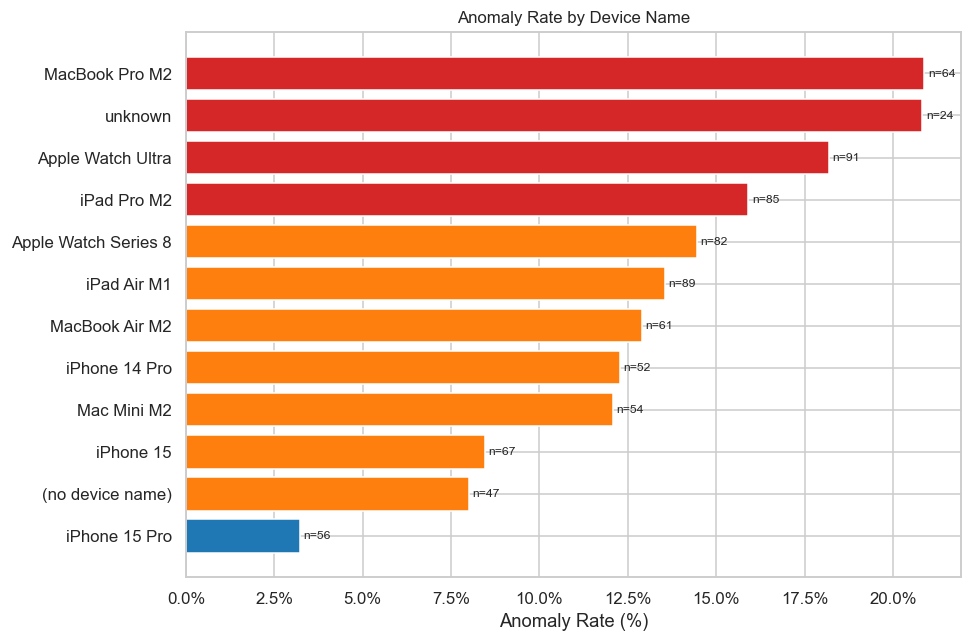

In [39]:
# 1.1 Anomaly rate by device name
dev_agg = (
    fact.groupby('device_name', dropna=False)
    .agg(
        anomaly_rate=('detected_anomaly', 'mean'),
        row_count=('run_id', 'count'),
        mean_latency=('latency_write_p99_ms', 'mean'),
    )
    .reset_index()
    .sort_values('anomaly_rate', ascending=True)
)
dev_agg['device_name'] = dev_agg['device_name'].fillna('(no device name)')

fig, ax = plt.subplots(figsize=(9, max(3, len(dev_agg) * 0.5)))
colors = ['#d62728' if r > 0.15 else '#ff7f0e' if r > 0.05 else '#1f77b4'
          for r in dev_agg['anomaly_rate']]
ax.barh(dev_agg['device_name'], dev_agg['anomaly_rate'] * 100, color=colors)
ax.set_xlabel('Anomaly Rate (%)')
ax.set_title('Anomaly Rate by Device Name')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
for i, (rate, count) in enumerate(zip(dev_agg['anomaly_rate'], dev_agg['row_count'])):
    ax.text(rate * 100 + 0.1, i, f'n={count}', va='center', fontsize=8)
plt.tight_layout()
plt.show()


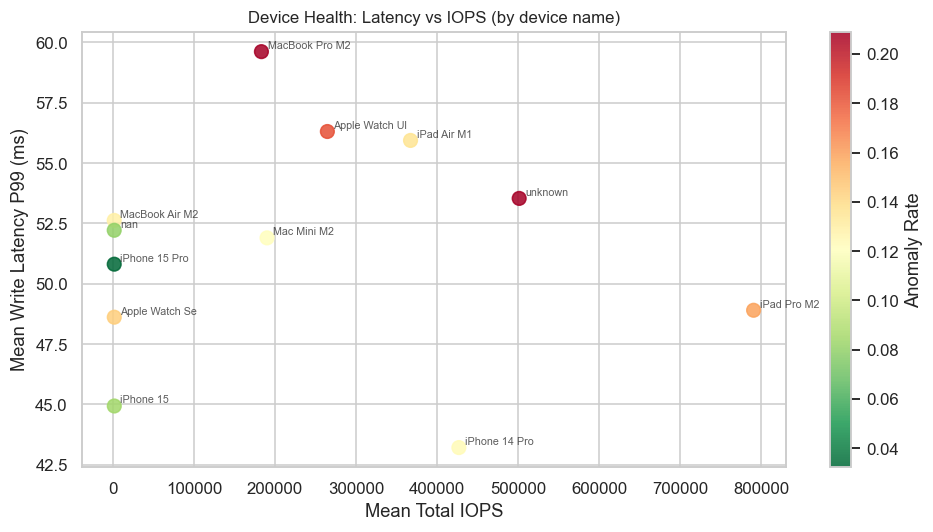

In [27]:
# 1.2 Latency vs IOPS scatter — colour by anomaly rate (aggregated by device_name)
plot_df = (
    fact.groupby('device_name', dropna=False)
    .agg(
        total_iops=('total_iops', 'mean'),
        latency_write_p99_ms=('latency_write_p99_ms', 'mean'),
        anomaly_rate=('detected_anomaly', 'mean'),
    )
    .reset_index()
    .dropna(subset=['total_iops', 'latency_write_p99_ms', 'anomaly_rate'])
)

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    plot_df['total_iops'],
    plot_df['latency_write_p99_ms'],
    c=plot_df['anomaly_rate'],
    cmap='RdYlGn_r',
    alpha=0.85,
    s=80,
)
cb = plt.colorbar(sc, ax=ax)
cb.set_label('Anomaly Rate')
for _, row in plot_df.iterrows():
    ax.annotate(str(row['device_name'])[:14], (row['total_iops'], row['latency_write_p99_ms']),
                fontsize=7, alpha=0.75, xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Mean Total IOPS')
ax.set_ylabel('Mean Write Latency P99 (ms)')
ax.set_title('Device Health: Latency vs IOPS (by device name)')
plt.tight_layout()
plt.show()


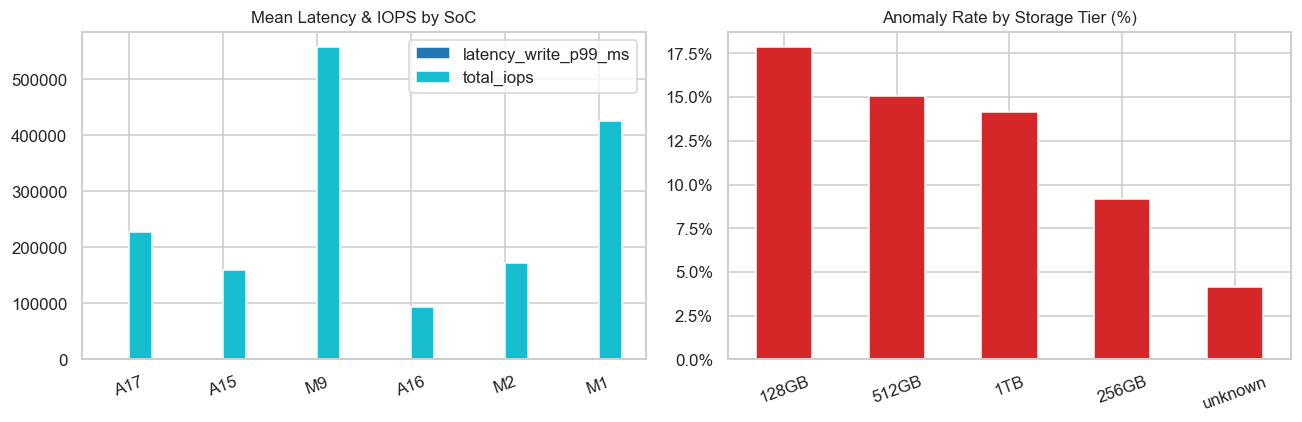

In [28]:
# 1.3 Per-SoC and storage-tier breakdown
if 'soc_model' in mart_device_overview.columns and 'storage_tier' in mart_device_overview.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    soc_agg = mart_device_overview.groupby('soc_model')[['latency_write_p99_ms', 'total_iops', 'anomaly_rate']].mean().sort_values('anomaly_rate', ascending=False)
    soc_agg[['latency_write_p99_ms', 'total_iops']].plot(kind='bar', ax=axes[0], colormap='tab10')
    axes[0].set_title('Mean Latency & IOPS by SoC')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=20)

    tier_agg = mart_device_overview.groupby('storage_tier')[['latency_write_p99_ms', 'anomaly_rate']].mean().sort_values('anomaly_rate', ascending=False)
    tier_agg['anomaly_rate'].mul(100).plot(kind='bar', ax=axes[1], color='#d62728')
    axes[1].set_title('Anomaly Rate by Storage Tier (%)')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

    plt.tight_layout()
    plt.show()


## Section 2 — Anomaly Timeline

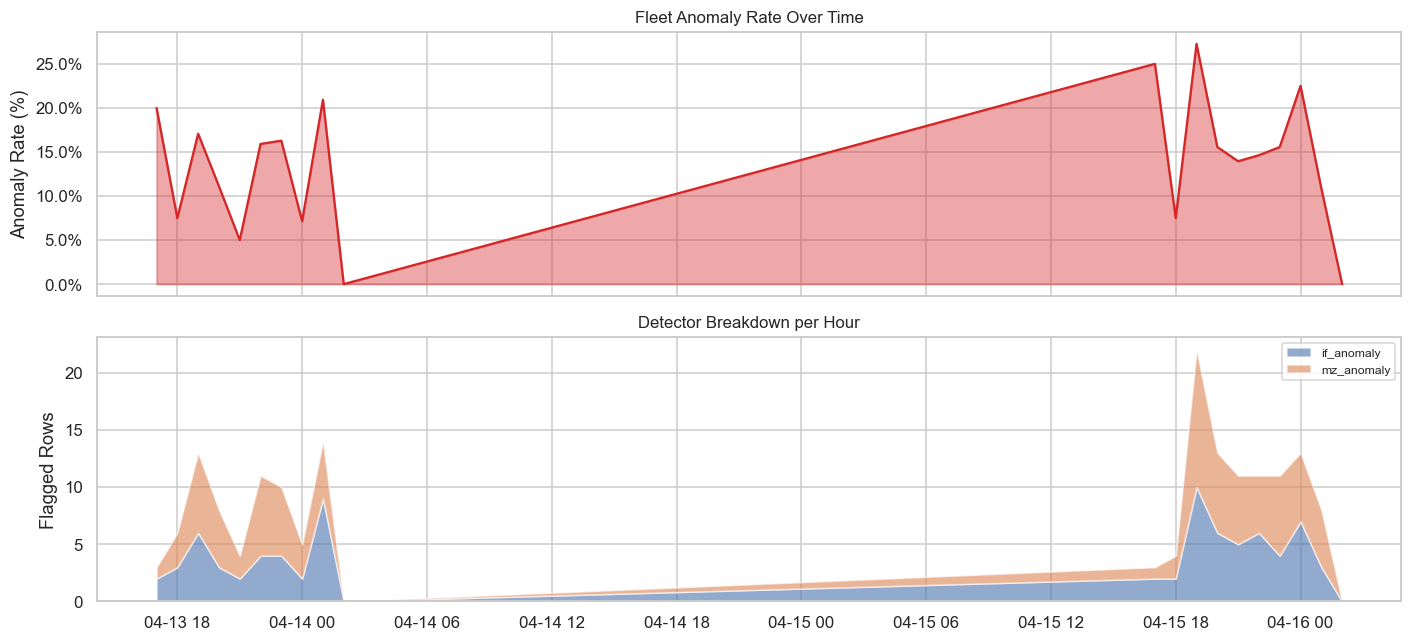

In [29]:
# 2.1 Fleet-wide anomaly rate over time
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].fill_between(mart_anomaly_timeline['hour_bucket'], mart_anomaly_timeline['anomaly_rate'] * 100,
                     alpha=0.4, color='#d62728', label='anomaly_rate')
axes[0].plot(mart_anomaly_timeline['hour_bucket'], mart_anomaly_timeline['anomaly_rate'] * 100,
             color='#d62728', linewidth=1.5)
axes[0].set_ylabel('Anomaly Rate (%)')
axes[0].set_title('Fleet Anomaly Rate Over Time')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# Stacked detector breakdown
det_cols = [c for c in ['if_anomaly', 'mz_anomaly'] if c in mart_anomaly_timeline.columns]
if det_cols:
    axes[1].stackplot(
        mart_anomaly_timeline['hour_bucket'],
        [mart_anomaly_timeline[c] for c in det_cols],
        labels=det_cols,
        alpha=0.6,
    )
    axes[1].legend(fontsize=8)
axes[1].set_ylabel('Flagged Rows')
axes[1].set_title('Detector Breakdown per Hour')

plt.tight_layout()
plt.show()


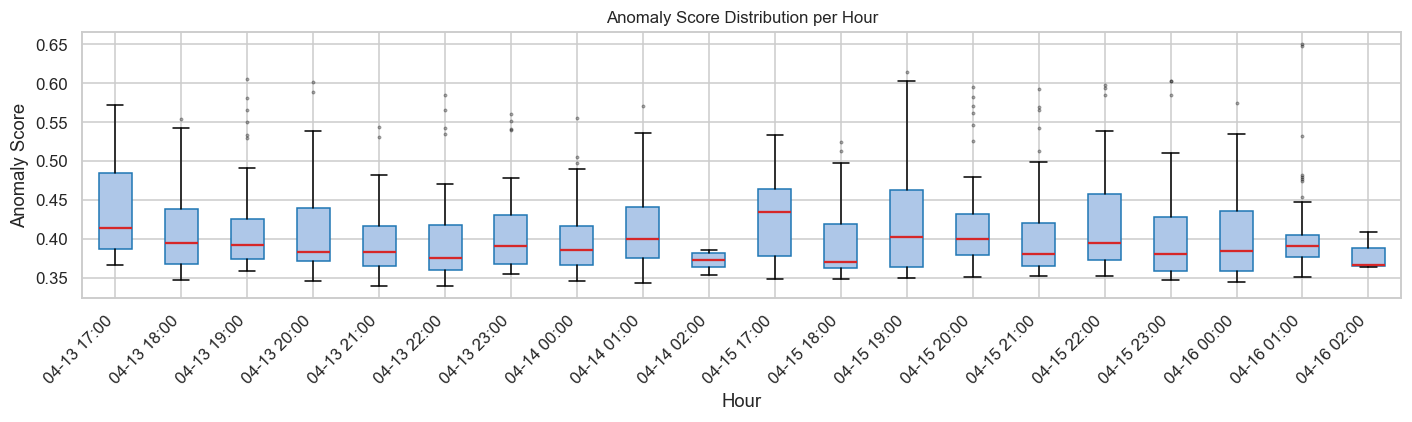

In [35]:
# 2.2 Anomaly score distribution over time (box per hour)
if fact['event_ts'].notna().any() and 'anomaly_score' in fact.columns:
    tf = fact.dropna(subset=['event_ts', 'anomaly_score']).copy()
    tf['hour_bucket'] = tf['event_ts'].dt.floor('h')
    hours = sorted(tf['hour_bucket'].unique())

    data_by_hour = [tf.loc[tf['hour_bucket'] == h, 'anomaly_score'].values for h in hours]
    tick_labels = [pd.Timestamp(h).strftime('%m-%d %H:%M') for h in hours]

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.boxplot(data_by_hour, tick_labels=tick_labels, patch_artist=True,
               boxprops=dict(facecolor='#aec7e8', color='#1f77b4'),
               medianprops=dict(color='#d62728', linewidth=1.5),
               flierprops=dict(marker='.', markersize=3, alpha=0.4))
    ax.set_title('Anomaly Score Distribution per Hour')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Anomaly Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## Section 3 — Root Cause Breakdown

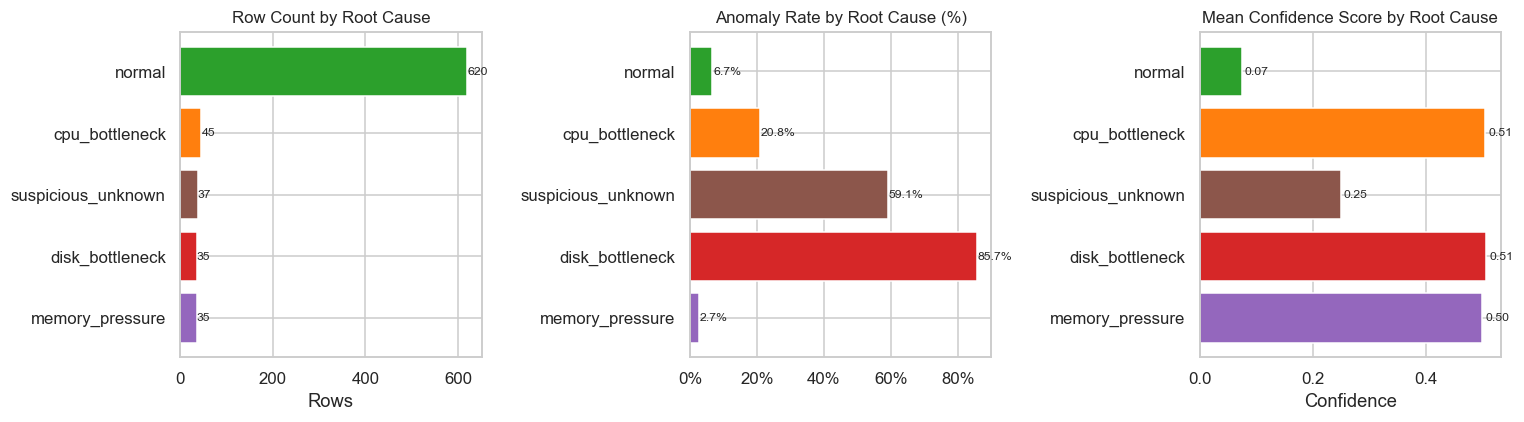

In [37]:
# 3.1 Root cause distribution — count + confidence
rc = mart_root_cause.sort_values('row_count', ascending=True)
palette = {'normal': '#2ca02c', 'disk_bottleneck': '#d62728',
           'cpu_bottleneck': '#ff7f0e', 'memory_pressure': '#9467bd',
           'suspicious_unknown': '#8c564b'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Count
colors = [palette.get(l, '#1f77b4') for l in rc['root_cause_label']]
axes[0].barh(rc['root_cause_label'], rc['row_count'], color=colors)
axes[0].set_title('Row Count by Root Cause')
axes[0].set_xlabel('Rows')
for i, v in enumerate(rc['row_count']):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=8)

# Anomaly rate
if 'anomaly_rate' in rc.columns:
    axes[1].barh(rc['root_cause_label'], rc['anomaly_rate'] * 100, color=colors)
    axes[1].set_title('Anomaly Rate by Root Cause (%)')
    axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    for i, v in enumerate(rc['anomaly_rate']):
        axes[1].text(v * 100 + 0.3, i, f'{v*100:.1f}%', va='center', fontsize=8)

# Confidence
if 'confidence_score' in rc.columns:
    axes[2].barh(rc['root_cause_label'], rc['confidence_score'], color=colors)
    axes[2].set_title('Mean Confidence Score by Root Cause')
    axes[2].set_xlabel('Confidence')
    for i, v in enumerate(rc['confidence_score']):
        axes[2].text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


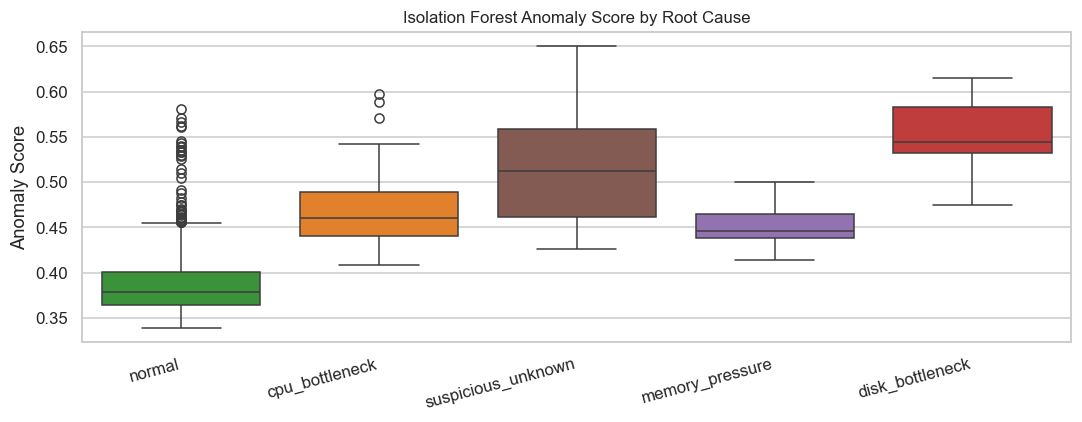

In [32]:
# 3.2 Anomaly score distribution by root cause label
if 'root_cause_label' in fact.columns and 'anomaly_score' in fact.columns:
    order = mart_root_cause.sort_values('row_count', ascending=False)['root_cause_label'].tolist()

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(
        data=fact,
        x='root_cause_label', y='anomaly_score',
        order=order,
        hue='root_cause_label',
        palette=palette,
        legend=False,
        ax=ax,
    )
    ax.set_title('Isolation Forest Anomaly Score by Root Cause')
    ax.set_xlabel('')
    ax.set_ylabel('Anomaly Score')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()


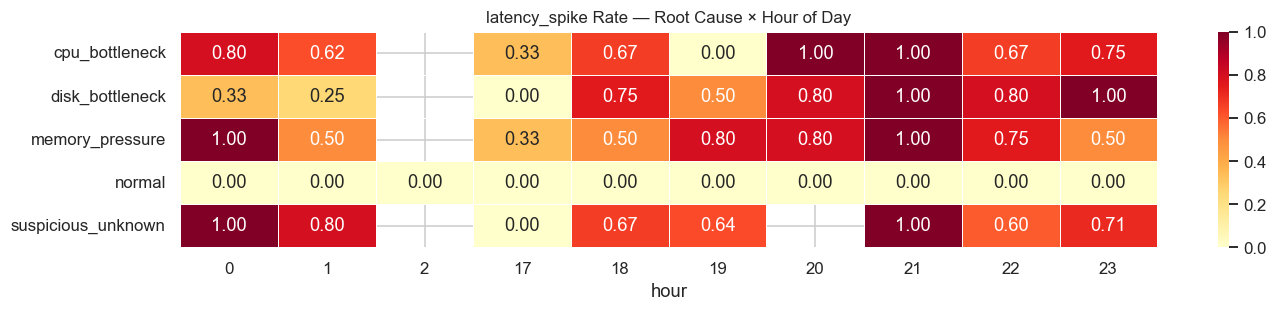

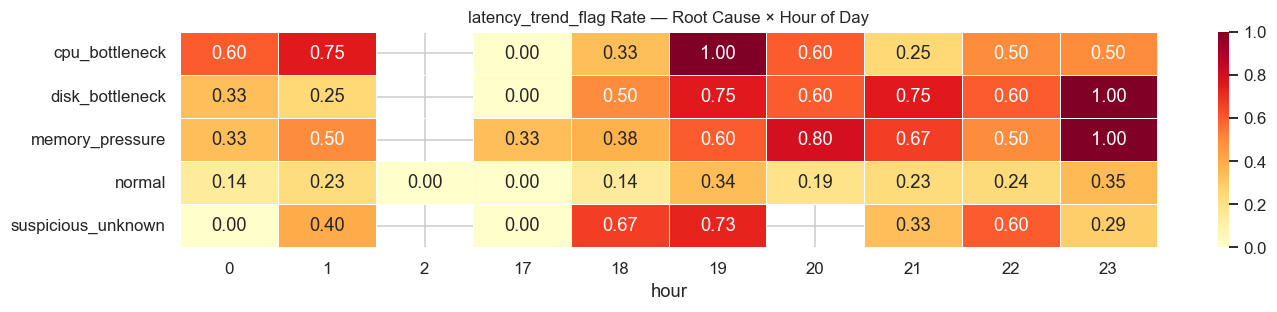

In [33]:
# 3.3 Latency spike and trend flag heatmap across root cause x hour
if 'root_cause_label' in fact.columns and fact['event_ts'].notna().any():
    hm = fact.dropna(subset=['event_ts']).copy()
    hm['hour'] = hm['event_ts'].dt.hour

    for flag in ['latency_spike', 'latency_trend_flag']:
        if flag not in hm.columns:
            continue
        pivot = hm.pivot_table(values=flag, index='root_cause_label',
                               columns='hour', aggfunc='mean')
        fig, ax = plt.subplots(figsize=(13, 3))
        sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
                    linewidths=0.4, ax=ax, vmin=0, vmax=1)
        ax.set_title(f'{flag} Rate — Root Cause × Hour of Day')
        ax.set_ylabel('')
        plt.tight_layout()
        plt.show()